# MMDCSM Research Reimplementation

This notebook reproduces the **methodological structure** of the paper's Multi-Modal Deep Clustering Survival Machines using synthetic multimodal survival data.

It is an independent implementation, not the authors' official code and not a clinical reproduction.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

from data import make_synthetic_survival_data, train_test_split_data
from train import fit_model
from model import mixture_log_likelihood
from metrics import concordance_index, cluster_ari, risk_separation

with open(ROOT / "configs" / "experiment.json") as f:
    cfg = json.load(f)

data = make_synthetic_survival_data(
    n=cfg["n_samples"],
    d1=cfg["modality_1_dim"],
    d2=cfg["modality_2_dim"],
    seed=cfg["seed"],
    censoring_rate=cfg["censoring_rate_target"]
)

train, test = train_test_split_data(data, seed=cfg["seed"])
print("Train subjects:", len(train["event"]))
print("Test subjects:", len(test["event"]))
print("Test censoring rate:", round(1-test["event"].mean(), 3))


Train subjects: 800
Test subjects: 200
Test censoring rate: 0.505


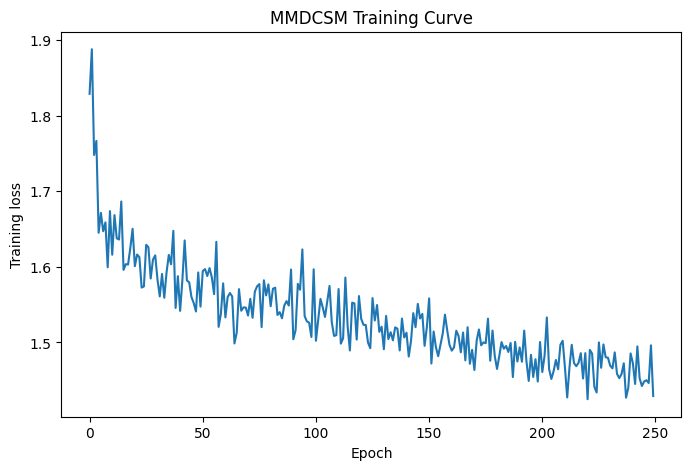

In [2]:
model, history = fit_model(
    train,
    d1=cfg["modality_1_dim"],
    d2=cfg["modality_2_dim"],
    hidden=cfg["hidden_dim"],
    latent=cfg["latent_dim"],
    epochs=cfg["epochs"],
    batch_size=cfg["batch_size"],
    lr=cfg["learning_rate"],
    seed=cfg["seed"]
)

plt.figure(figsize=(8,5))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("MMDCSM Training Curve")
plt.show()


In [3]:
model.eval()
with torch.no_grad():
    out = model(
        torch.tensor(test["x1"]),
        torch.tensor(test["x2"])
    )
    log_likelihood = mixture_log_likelihood(
        out,
        torch.tensor(test["time"]),
        torch.tensor(test["event"])
    ).item()

weights = out["weights"].numpy()
clusters = weights.argmax(axis=1)
risk = (weights / out["scale"].numpy()[None, :]).sum(axis=1)

results = {
    "negative_log_likelihood": -log_likelihood,
    "concordance_index": concordance_index(
        test["time"], test["event"], risk
    ),
    "cluster_ARI": cluster_ari(
        test["subtype"], clusters
    ),
    "risk_separation": risk_separation(
        test["time"], test["event"], clusters, risk
    )
}

pd.DataFrame([results])


,negative_log_likelihood,concordance_index,cluster_ARI,risk_separation
0,1.627851,0.734586,0.530591,0.120271


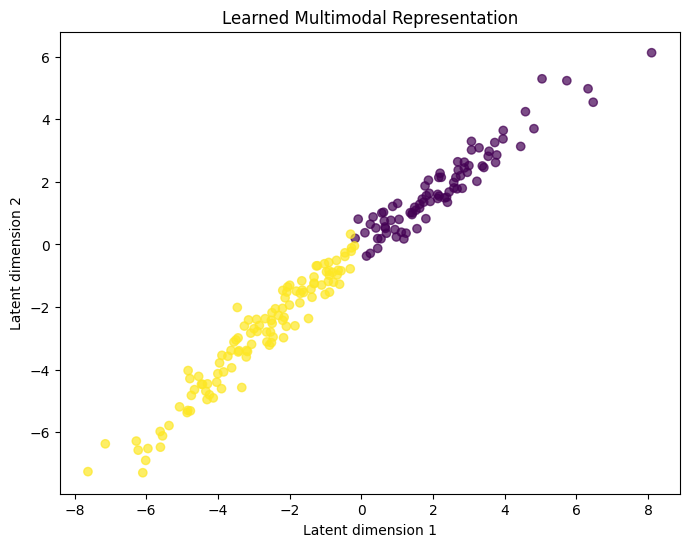

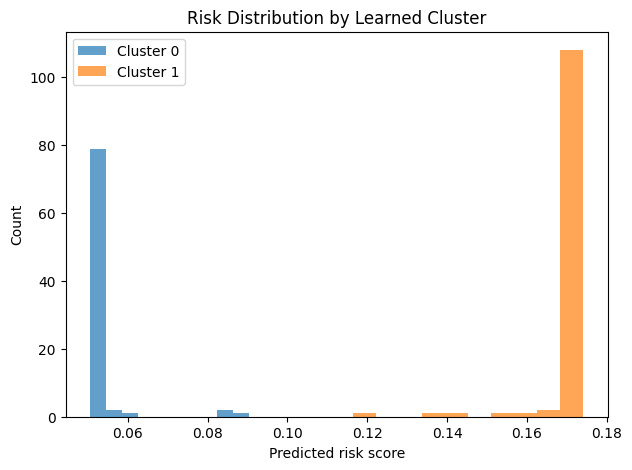

In [4]:
z = out["z"].numpy()

plt.figure(figsize=(8,6))
plt.scatter(z[:,0], z[:,1], c=clusters, alpha=0.7)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Learned Multimodal Representation")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(risk[clusters == 0], alpha=0.7, label="Cluster 0")
plt.hist(risk[clusters == 1], alpha=0.7, label="Cluster 1")
plt.xlabel("Predicted risk score")
plt.ylabel("Count")
plt.title("Risk Distribution by Learned Cluster")
plt.legend()
plt.show()


## Interpretation

A successful run should recover some of the latent two-subtype structure embedded in the synthetic data.

The key point is not the absolute metric value. The experiment demonstrates the complete pipeline:

**multimodal inputs → modality-specific encoders → fused latent representation → Weibull mixture → survival likelihood → latent subtype assignment.**

The next research step would be benchmarking this architecture against Cox PH, DeepSurv, and single-modality ablations on a public survival dataset.
